
# KENDA-CH1 IAU consistency & cloud-cover diagnostics — exp 801 vs 802

This notebook does three things, for the analysis-increment period 4–10 Oct 2025:

1. **Checks `lff(T) + inc(T) ≈ iaf(T)`** for `T`, `QC`, `QV` and quantifies the
   residual (`iaf - (lff + inc)`), which is expected to be small but non-zero
   because `iaf` actually comes from `iff(T-1)` propagated through a 10-minute
   IAU window, not directly from `lff(T)`.
2. **Plots horizontal and vertical cross-sections** of the increments
   (`inc`) and of `iaf` vs `lff` for `T`, `QC`, `QV`, side by side for
   experiments 801 and 802.
3. **Compares cloud cover** (`CLC` / `CLCT`) between `iaf` and `lff`, since
   `CLC` is diagnostic and not present in `inc` — this is the field most
   relevant to the "spurious cloud increase" question that motivated 802.

**API and paths**: field access follows the confirmed working pattern from
the ICON→NWCSAF regridding script — `fs.sel({"parameter.variable": name})`
then `.to_xarray()`, pulling `longitude`/`latitude` and the data variable out
of the resulting `Dataset` — rather than `shortName=`/`.to_latlon()`, which
isn't the right eccodes call here. `ECCODES_VERSION_CHECK_OFF` is set before
`earthkit.data` is imported, same as in that script.

The archive root is `/store_new/mch/msopr/jdelbeke/ICON_TST/<exp>/`, confirmed
by that script for `FG25/det/lff*`. The `ANA25/det/inc*` and `iaf*` paths
follow the same convention but weren't directly exercised there — the
exploration cell below checks all four file kinds exist before anything else
runs.


## 0.1 Imports & configuration

In [1]:

import os
os.environ["ECCODES_VERSION_CHECK_OFF"] = "1"  # must be set before importing earthkit.data

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import earthkit.data as ekd
from scipy.spatial import cKDTree


In [2]:

# --- experiments -----------------------------------------------------------
EXP_IDS = ["801", "802"]

# Try these in order for each exp_id; first one that exists on disk wins.
# The first entry is confirmed (used by the ICON->NWCSAF script for lff);
# the others are kept as fallbacks from the original brief in case any
# experiment/file kind actually lives elsewhere.
BASE_CANDIDATES = [
    "/store_new/mch/msopr/jdelbeke/ICON_TST/{exp}",
    "/store_new/s83/jdelbeke/EXP_TST/{exp}",
    "$SCRATCH/cache/{exp}",
]
YEAR_SUFFIX = "25"  # -> FG25 / ANA25

# --- times -------------------------------------------------------------
# Single time used for the detailed consistency check + cross-sections.
CHECK_TIME = "2025100507"

# Morning hours where the CLCT bias jump is largest (brief, section 6) -
# used for the increment comparison and the CLCT time series.
FOCUS_TIMES = [f"20251005{h:02d}" for h in range(5, 10)]  # 05-09 UTC, 5 Oct

# Full cycling period, for an optional longer time series.
ALL_TIMES = [f"202510{d:02d}{h:02d}" for d in range(4, 10) for h in range(24)]

# --- levels ------------------------------------------------------------
# ICON model levels: 1 = model top, 80 = surface. Cloud-relevant range per brief.
LEVELS_OF_INTEREST = list(range(40, 61))
PLOT_LEVELS = [45, 50, 55, 60]  # subset actually rendered in the demo maps below

# --- variables -----------------------------------------------------------
# "parameter.variable" name as used by fs.sel({"parameter.variable": ...}).
# Brief gives the same name in inc and in the full-state (iaf/lff) files.
VARIABLES = {
    "T":  "T",
    "QV": "QV",
    "QC": "QC",
}

# --- vertical cross-section transect (edit to whatever line you want) ------
# (lat, lon) endpoints; a great-circle line between them is sampled below.
TRANSECT_START = (45.85, 6.00)   # SW Switzerland
TRANSECT_END   = (47.80, 10.50)  # NE Switzerland
N_TRANSECT_PTS = 200

OUTPUT_DIR = Path("./figures")
OUTPUT_DIR.mkdir(exist_ok=True)


## 1. Data-access helpers

In [3]:

def resolve_base(exp_id):
    '''First existing archive directory for this experiment.'''
    checked = []
    for tmpl in BASE_CANDIDATES:
        candidate = os.path.expandvars(tmpl.format(exp=exp_id))
        checked.append(candidate)
        if os.path.isdir(candidate):
            return candidate
    raise FileNotFoundError(
        f"No archive directory found for exp {exp_id}. Checked:\n  "
        + "\n  ".join(checked)
        + "\nConfirm the correct path on Balfrin and add it to BASE_CANDIDATES."
    )


def file_path(exp_id, kind, time):
    '''kind: "lff" | "iff" (FG<YY>/det) or "inc" | "iaf" (ANA<YY>/det).'''
    base = resolve_base(exp_id)
    sub = ("FG" if kind in ("lff", "iff") else "ANA") + YEAR_SUFFIX
    return os.path.join(base, sub, "det", f"{kind}{time}")


def open_fs(path):
    '''Load a GRIB file as an earthkit FieldList, same call as the reference script.'''
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    return ekd.from_source("file", path).to_fieldlist()


In [4]:

def get_level(field):
    '''Try a few metadata keys for the vertical level. The exploration cell
    below prints what a real field actually exposes; adjust this list if
    none of these match.'''
    for key in ("level", "levelist", "topLevel", "parameter.level"):
        try:
            v = field.metadata(key)
            if v is not None:
                return v
        except Exception:
            continue
    return None


def _field_to_arrays(field, var_name):
    '''One earthkit Field -> (lon, lat, data), all 1D, via the confirmed
    fs.sel(...)[i].to_xarray() pattern.'''
    xa = field.to_xarray()
    name = var_name if var_name in xa else list(xa.data_vars)[0]
    lon = np.asarray(xa["longitude"].values).ravel()
    lat = np.asarray(xa["latitude"].values).ravel()
    arr = np.asarray(xa[name].values).ravel()
    return lon, lat, arr


def get_profile(fs, var_name, levels=None):
    '''
    Select every field matching this parameter.variable name and stack them.

    Returns
    -------
    lev      : None for a single-level field (e.g. CLCT), else a sorted 1D
               array of level indices (1 = model top .. 80 = surface).
    lon, lat : 1D coordinate arrays (identical for every level of a variable).
    arr      : (n_cells,) for a single-level field, else (n_levels, n_cells).
    '''
    sel = fs.sel({"parameter.variable": var_name})
    if len(sel) == 0:
        raise KeyError(f"parameter.variable={var_name!r} not found in this file")
    fields = list(sel)

    if len(fields) == 1:
        lon, lat, arr = _field_to_arrays(fields[0], var_name)
        return None, lon, lat, arr

    lev = np.array([get_level(f) for f in fields])
    order = np.argsort(lev)
    fields = [fields[i] for i in order]
    lev = lev[order]

    if levels is not None:
        keep = np.isin(lev, levels)
        fields = [f for f, k in zip(fields, keep) if k]
        lev = lev[keep]

    lon = lat = None
    rows = []
    for f in fields:
        flon, flat, arr = _field_to_arrays(f, var_name)
        if lon is None:
            lon, lat = flon, flat
        rows.append(arr)

    return lev, lon, lat, np.stack(rows)



## 0.2 One-time exploration — **run this first**

Checks that all four file kinds exist for both experiments at `CHECK_TIME`
(this is the thing to look at if `ANA25/det/inc*` or `iaf*` turn out to live
somewhere different from `FG25/det/lff*`), then prints what a real field's
`to_xarray()` conversion and `get_level()` actually return, so the two
helpers above can be corrected before anything downstream is trusted.


In [5]:

print("--- file existence check ---")
for exp_id in EXP_IDS:
    for kind in ("lff", "iff", "inc", "iaf"):
        p = file_path(exp_id, kind, CHECK_TIME)
        print(f"  {'OK ' if os.path.exists(p) else 'MISSING'}  {p}")


--- file existence check ---
  OK   /store_new/mch/msopr/jdelbeke/ICON_TST/801/FG25/det/lff2025100507
  OK   /store_new/mch/msopr/jdelbeke/ICON_TST/801/FG25/det/iff2025100507
  OK   /store_new/mch/msopr/jdelbeke/ICON_TST/801/ANA25/det/inc2025100507
  OK   /store_new/mch/msopr/jdelbeke/ICON_TST/801/ANA25/det/iaf2025100507
  OK   /store_new/mch/msopr/jdelbeke/ICON_TST/802/FG25/det/lff2025100507
  OK   /store_new/mch/msopr/jdelbeke/ICON_TST/802/FG25/det/iff2025100507
  OK   /store_new/mch/msopr/jdelbeke/ICON_TST/802/ANA25/det/inc2025100507
  OK   /store_new/mch/msopr/jdelbeke/ICON_TST/802/ANA25/det/iaf2025100507


In [6]:

print("--- field inspection (exp 801, iaf, T) ---")
fs = open_fs(file_path("801", "iaf", CHECK_TIME))
print(f"{len(fs)} fields in file")

sel = fs.sel({"parameter.variable": "T"})
print(f"'T' fields found: {len(sel)} (expect ~80, one per model level)")

f0 = sel[0]
xa0 = f0.to_xarray()
print("single-field to_xarray() dims:", dict(xa0.dims))
print("single-field to_xarray() data_vars:", list(xa0.data_vars))
print("get_level(f0) ->", get_level(f0))
print("(if get_level is None, inspect xa0.coords / f0.metadata(namespace=...) "
      "to find the right key, then add it to get_level's key list above)")


--- field inspection (exp 801, iaf, T) ---
1483 fields in file
'T' fields found: 80 (expect ~80, one per model level)
single-field to_xarray() dims: {'values': 1147980}
single-field to_xarray() data_vars: ['T']
get_level(f0) -> 1
(if get_level is None, inspect xa0.coords / f0.metadata(namespace=...) to find the right key, then add it to get_level's key list above)


/tmp/ipykernel_101480/696120500.py:10: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("single-field to_xarray() dims:", dict(xa0.dims))



## 2. Consistency check: `lff(T) + inc(T) ≈ iaf(T)`

For each experiment and variable, loads `lff`, `inc`, `iaf` at `CHECK_TIME`
and computes `residual = iaf - (lff + inc)` on every level of interest.


In [7]:

def consistency_check(exp_id, time, var_key, levels=None):
    var_name = VARIABLES[var_key]
    lff = open_fs(file_path(exp_id, "lff", time))
    inc = open_fs(file_path(exp_id, "inc", time))
    iaf = open_fs(file_path(exp_id, "iaf", time))

    lev_lff, lon, lat, a_lff = get_profile(lff, var_name, levels)
    lev_inc, _,   _,   a_inc = get_profile(inc, var_name, levels)
    lev_iaf, _,   _,   a_iaf = get_profile(iaf, var_name, levels)

    assert np.array_equal(lev_lff, lev_inc) and np.array_equal(lev_lff, lev_iaf), \
        "level sets differ between lff/inc/iaf for this variable - align before comparing"

    residual = a_iaf - (a_lff + a_inc)
    return lev_lff, lon, lat, residual, a_lff, a_inc, a_iaf


In [8]:

rows = []
cache = {}  # (exp, var) -> (lev, lon, lat, residual, lff, inc, iaf)
for exp_id in EXP_IDS:
    for var_key in VARIABLES:
        lev, lon, lat, residual, a_lff, a_inc, a_iaf = consistency_check(
            exp_id, CHECK_TIME, var_key, LEVELS_OF_INTEREST)
        cache[(exp_id, var_key)] = (lev, lon, lat, residual, a_lff, a_inc, a_iaf)
        for l, r in zip(lev, residual):
            rows.append(dict(
                exp=exp_id, var=var_key, level=int(l),
                mean=np.nanmean(r), std=np.nanstd(r),
                max_abs=np.nanmax(np.abs(r)),
            ))

residual_stats = pd.DataFrame(rows)
residual_stats


,exp,var,level,mean,std,max_abs
0,801,T,40,0.006286,0.101673,2.678435
1,801,T,41,0.006695,0.102159,2.823712
2,801,T,42,0.006577,0.102916,2.988725
3,801,T,43,0.006130,0.104032,3.242350
4,801,T,44,0.005289,0.104730,2.135270
...,...,...,...,...,...,...
121,802,QC,56,-0.000003,0.000034,0.001085
122,802,QC,57,-0.000003,0.000034,0.001268
123,802,QC,58,-0.000003,0.000033,0.001346
124,802,QC,59,-0.000002,0.000032,0.001299


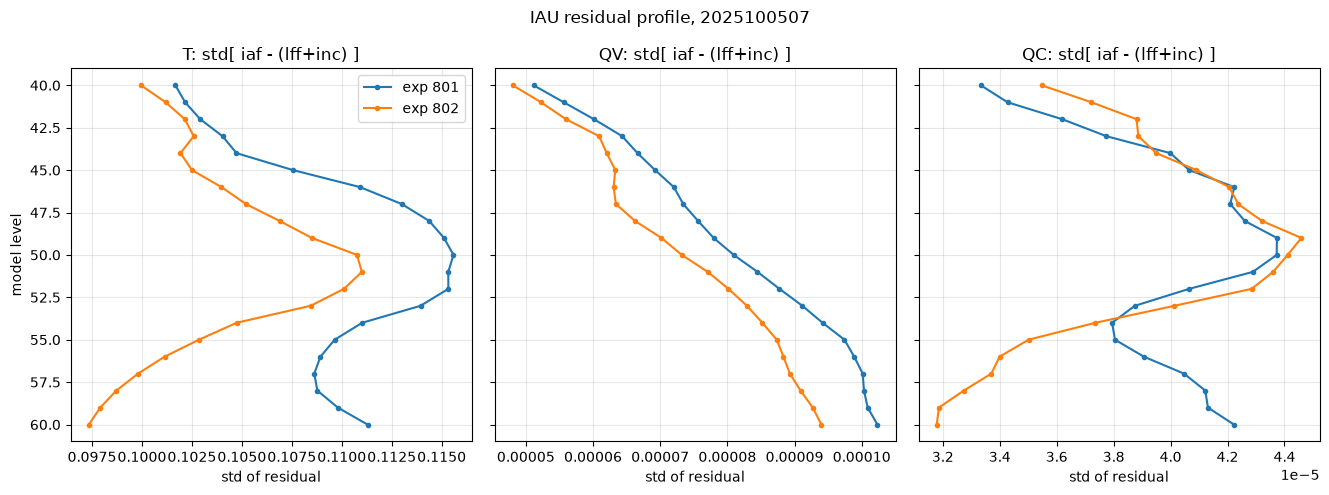

In [9]:

# vertical profile of the residual's std per level, both exps overlaid
fig, axes = plt.subplots(1, len(VARIABLES), figsize=(4.5 * len(VARIABLES), 5), sharey=True)
for ax, var_key in zip(axes, VARIABLES):
    for exp_id in EXP_IDS:
        sub = residual_stats[(residual_stats["var"] == var_key) &
                              (residual_stats["exp"] == exp_id)].sort_values("level")
        ax.plot(sub["std"], sub["level"], marker=".", label=f"exp {exp_id}")
    ax.invert_yaxis()  # level 1 (model top) at the top of the plot
    ax.set_title(f"{var_key}: std[ iaf - (lff+inc) ]")
    ax.set_xlabel("std of residual")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("model level")
axes[0].legend()
plt.suptitle(f"IAU residual profile, {CHECK_TIME}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "residual_profile.png", dpi=150)
plt.show()


In [10]:

def plot_horizontal(lat, lon, values, title, ax=None, vlim=None, cmap="RdBu_r", label=""):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))
    finite = values[np.isfinite(values)]
    vmax = vlim if vlim is not None else (np.nanpercentile(np.abs(finite), 99) if finite.size else 1.0)
    sc = ax.scatter(lon, lat, c=values, s=2, cmap=cmap, vmin=-vmax, vmax=vmax)
    cb = plt.colorbar(sc, ax=ax, shrink=0.8)
    if label:
        cb.set_label(label)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("lon"); ax.set_ylabel("lat")
    ax.set_aspect("equal")
    return ax


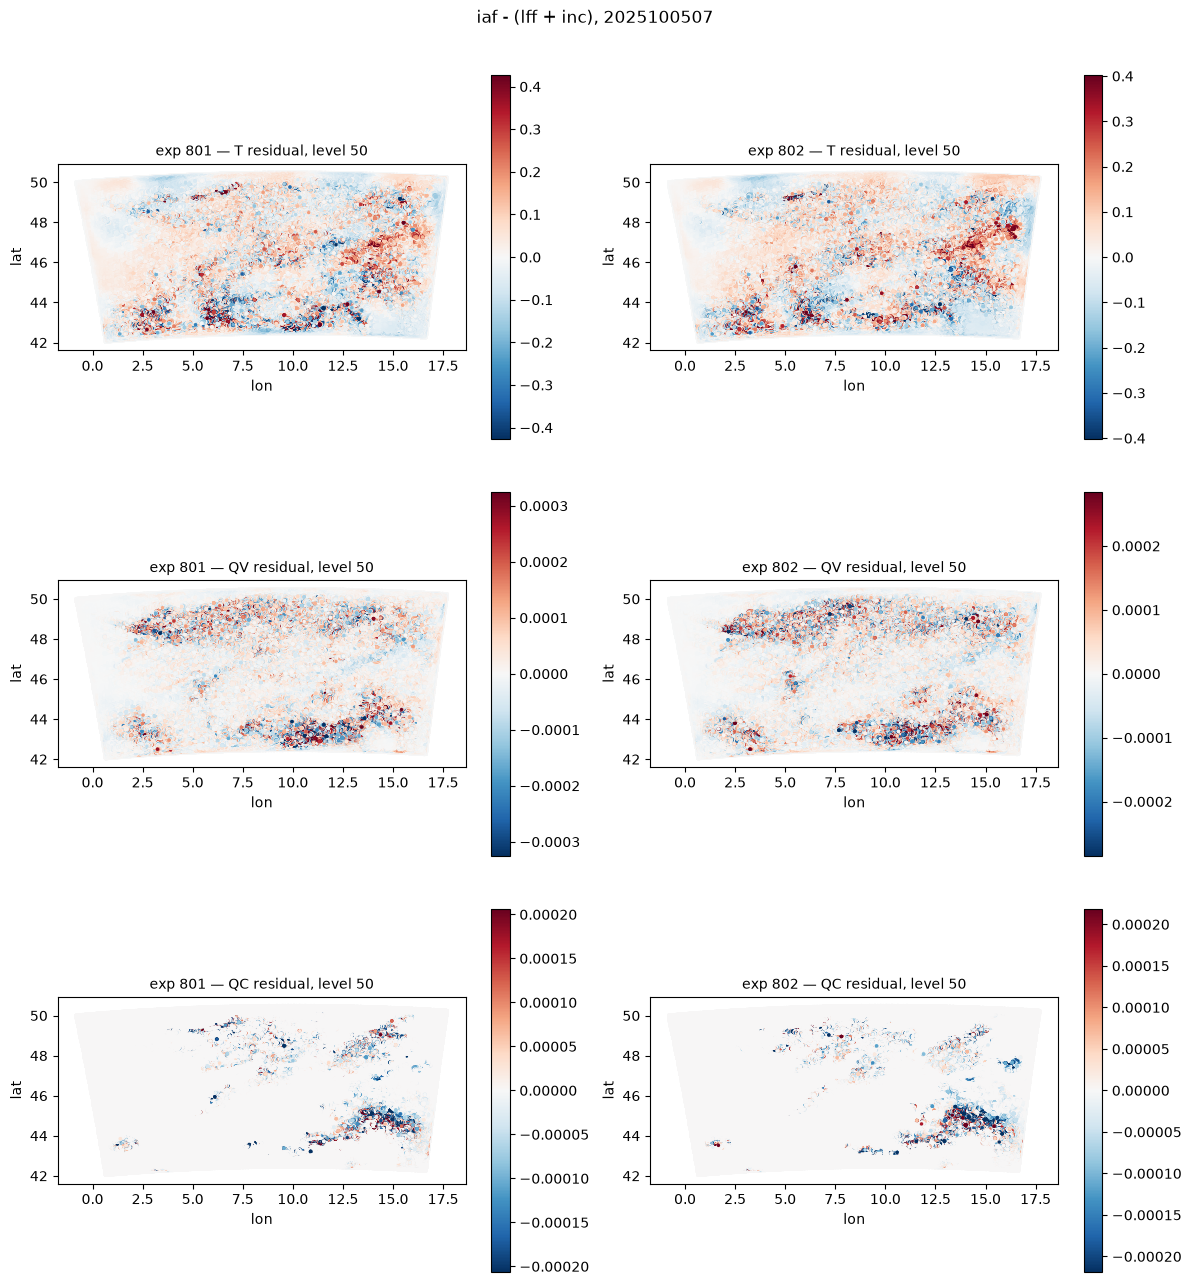

In [11]:

# horizontal maps of the residual, one row per variable, one column per exp,
# at a single representative level
demo_level = 50

fig, axes = plt.subplots(len(VARIABLES), len(EXP_IDS),
                          figsize=(6 * len(EXP_IDS), 4.5 * len(VARIABLES)))
for row, var_key in enumerate(VARIABLES):
    for col, exp_id in enumerate(EXP_IDS):
        lev, lon, lat, residual, *_ = cache[(exp_id, var_key)]
        k = int(np.where(lev == demo_level)[0][0])
        plot_horizontal(lat, lon, residual[k],
                         f"exp {exp_id} — {var_key} residual, level {demo_level}",
                         ax=axes[row, col])
plt.suptitle(f"iaf - (lff + inc), {CHECK_TIME}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"residual_maps_lev{demo_level}.png", dpi=150)
plt.show()



## 3. Horizontal cross-sections of the increments (`inc`)

`T`, `QC`, `QV` increments at selected levels, 801 vs 802 side by side.
Runs for `CHECK_TIME` and `PLOT_LEVELS` by default — wrap in a loop over
`FOCUS_TIMES` to render all five morning hours (commented at the bottom).


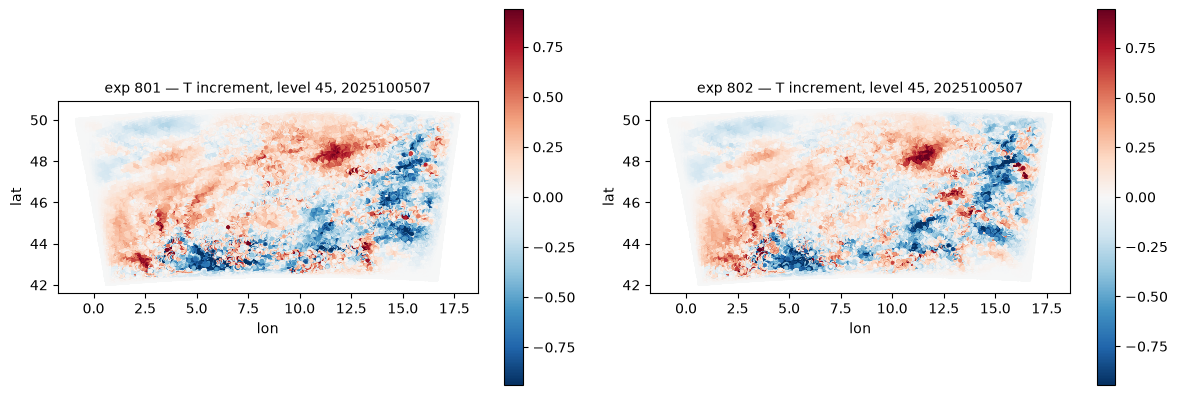

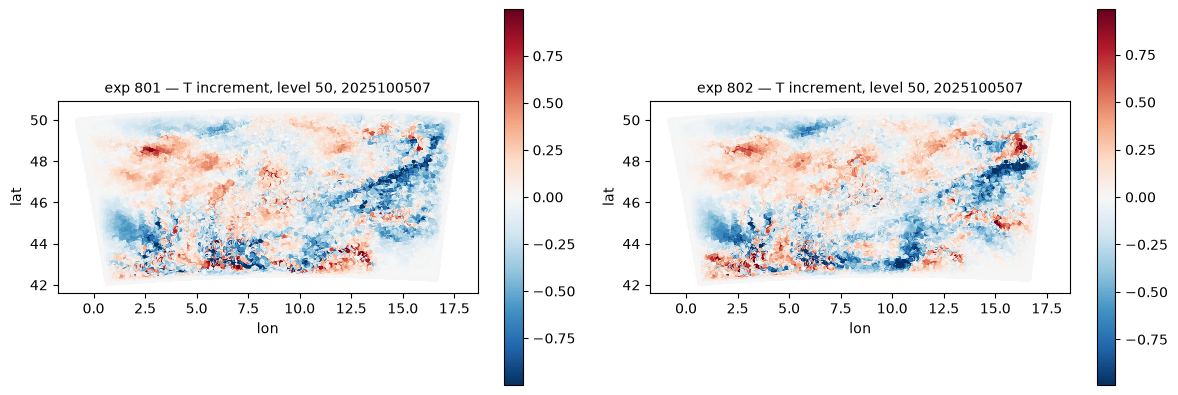

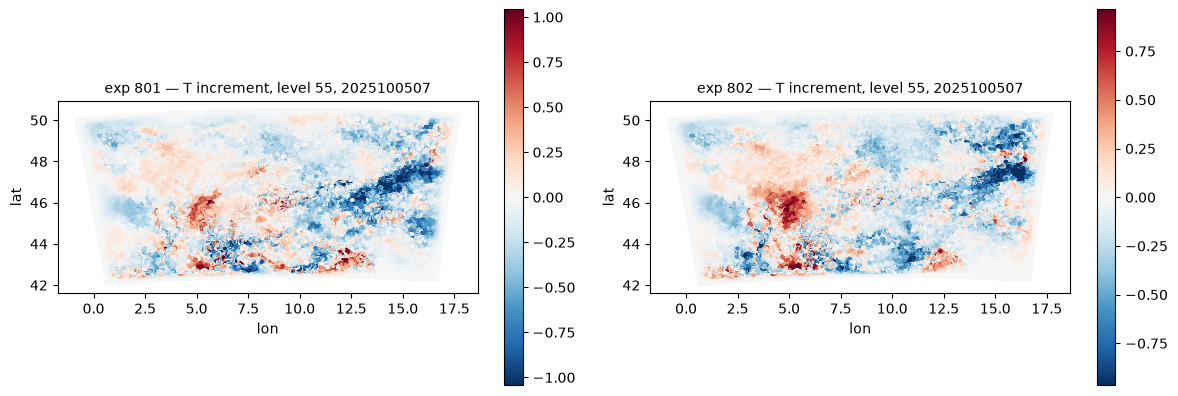

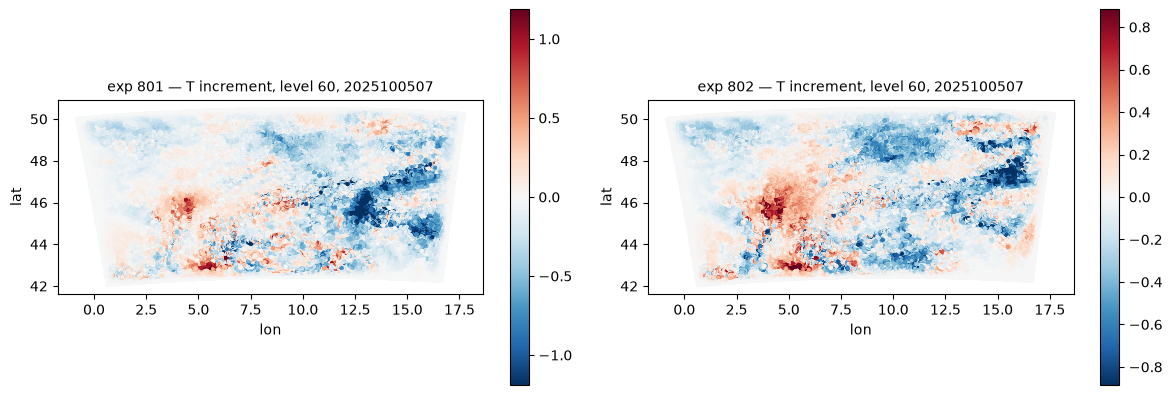

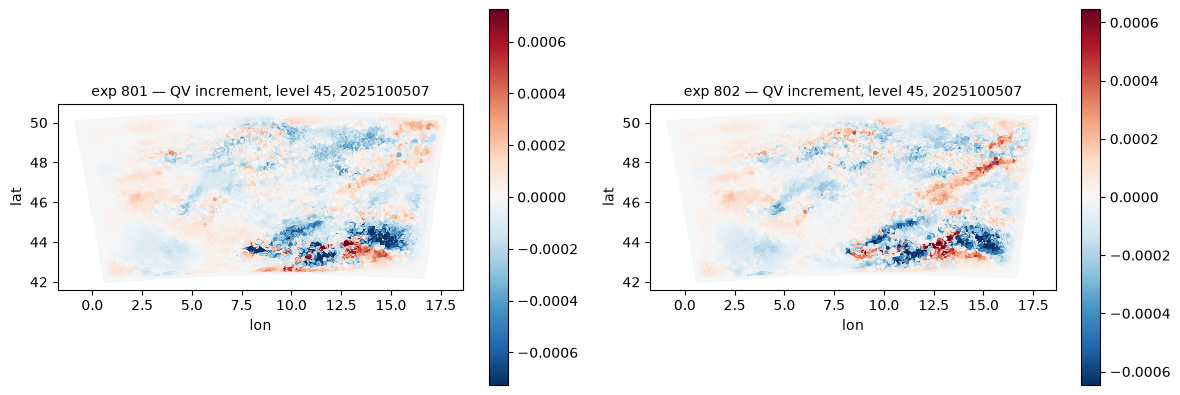

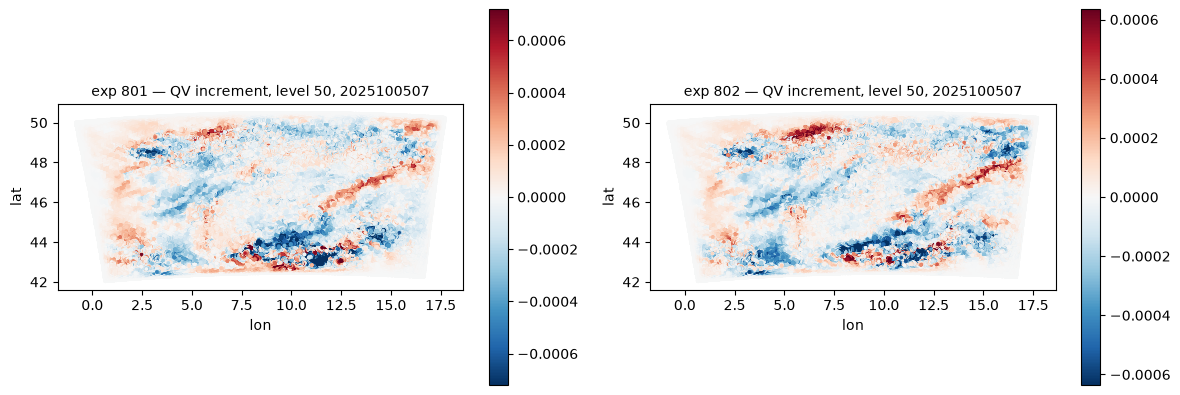

In [ ]:

def plot_inc_comparison(time, var_key, level):
    var_name = VARIABLES[var_key]
    fig, axes = plt.subplots(1, len(EXP_IDS), figsize=(6 * len(EXP_IDS), 5))
    for ax, exp_id in zip(axes, EXP_IDS):
        inc = open_fs(file_path(exp_id, "inc", time))
        lev, lon, lat, arr = get_profile(inc, var_name, [level])
        plot_horizontal(lat, lon, arr[0],
                         f"exp {exp_id} — {var_key} increment, level {level}, {time}",
                         ax=ax)
    plt.tight_layout()
    fname = OUTPUT_DIR / f"inc_{var_key}_lev{level}_{time}.png"
    plt.savefig(fname, dpi=150)
    plt.show()


for var_key in VARIABLES:
    for level in PLOT_LEVELS:
        plot_inc_comparison(CHECK_TIME, var_key, level)

# to cover the full morning window instead of one time, use:
# for time in FOCUS_TIMES:
#     for var_key in VARIABLES:
#         for level in PLOT_LEVELS:
#             plot_inc_comparison(time, var_key, level)



## 4. Vertical cross-sections: `iaf` vs `lff`

Samples both fields along a great-circle transect (`TRANSECT_START` →
`TRANSECT_END`) at every level of interest, via nearest-neighbour lookup on
the unstructured grid, then plots `iaf`, `lff`, and `iaf - lff` stacked.


In [ ]:

def build_tree(lat, lon):
    '''KDTree in unit-sphere xyz, for accurate great-circle nearest neighbours.'''
    la, lo = np.deg2rad(lat), np.deg2rad(lon)
    xyz = np.column_stack([np.cos(la) * np.cos(lo),
                            np.cos(la) * np.sin(lo),
                            np.sin(la)])
    return cKDTree(xyz)


def nearest_cells(tree, lats, lons):
    la, lo = np.deg2rad(lats), np.deg2rad(lons)
    xyz = np.column_stack([np.cos(la) * np.cos(lo),
                            np.cos(la) * np.sin(lo),
                            np.sin(la)])
    _, idx = tree.query(xyz)
    return idx


def great_circle_points(p0, p1, n):
    '''n (lat, lon, cumulative_km) points along the great circle p0 -> p1.'''
    la0, lo0, la1, lo1 = map(np.deg2rad, [p0[0], p0[1], p1[0], p1[1]])
    d = np.arccos(np.clip(np.sin(la0) * np.sin(la1) +
                           np.cos(la0) * np.cos(la1) * np.cos(lo1 - lo0), -1, 1))
    f = np.linspace(0, 1, n)
    A, B = np.sin((1 - f) * d) / np.sin(d), np.sin(f * d) / np.sin(d)
    x = A * np.cos(la0) * np.cos(lo0) + B * np.cos(la1) * np.cos(lo1)
    y = A * np.cos(la0) * np.sin(lo0) + B * np.cos(la1) * np.sin(lo1)
    z = A * np.sin(la0) + B * np.sin(la1)
    lat = np.rad2deg(np.arctan2(z, np.sqrt(x**2 + y**2)))
    lon = np.rad2deg(np.arctan2(y, x))
    dist_km = d * 6371.0 * f
    return lat, lon, dist_km


In [ ]:

def plot_vertical_cross_section(time, var_key, exp_id):
    var_name = VARIABLES[var_key]
    iaf = open_fs(file_path(exp_id, "iaf", time))
    lff = open_fs(file_path(exp_id, "lff", time))

    lev, lon, lat, iaf_full = get_profile(iaf, var_name, LEVELS_OF_INTEREST)
    _,   _,   _,   lff_full = get_profile(lff, var_name, LEVELS_OF_INTEREST)

    tree = build_tree(lat, lon)
    lat_t, lon_t, dist_t = great_circle_points(TRANSECT_START, TRANSECT_END, N_TRANSECT_PTS)
    idx = nearest_cells(tree, lat_t, lon_t)

    iaf_xsec, lff_xsec = iaf_full[:, idx], lff_full[:, idx]
    diff_xsec = iaf_xsec - lff_xsec

    fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)
    panels = [(iaf_xsec, f"iaf {var_key}", "viridis"),
              (lff_xsec, f"lff {var_key}", "viridis"),
              (diff_xsec, f"iaf - lff {var_key}", "RdBu_r")]
    for ax, (data, title, cmap) in zip(axes, panels):
        vkw = {} if cmap == "viridis" else dict(
            vmin=-np.nanpercentile(np.abs(data), 99),
            vmax=np.nanpercentile(np.abs(data), 99))
        pc = ax.pcolormesh(dist_t, lev, data, shading="auto", cmap=cmap, **vkw)
        ax.invert_yaxis()  # level 1 (model top) at the top of the plot
        ax.set_ylabel("model level")
        ax.set_title(f"exp {exp_id} — {title}, {time}", fontsize=10)
        plt.colorbar(pc, ax=ax, shrink=0.85)
    axes[-1].set_xlabel("distance along transect [km]  (start -> end)")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"xsec_{var_key}_{exp_id}_{time}.png", dpi=150)
    plt.show()


for exp_id in EXP_IDS:
    for var_key in VARIABLES:
        plot_vertical_cross_section(CHECK_TIME, var_key, exp_id)



## 5. Cloud cover: `iaf` vs `lff` (`CLC`, `CLCT`)

`CLC`/`CLCT` are diagnostic fields, not carried in `inc`, so they can only
be compared directly between `iaf` and `lff`. `Δ_CLCT = iaf.CLCT - lff.CLCT`;
positive means the analysis step added cloud relative to the first guess.


In [ ]:

def clc_diff(time, exp_id):
    iaf = open_fs(file_path(exp_id, "iaf", time))
    lff = open_fs(file_path(exp_id, "lff", time))
    lev, lon, lat, clc_iaf = get_profile(iaf, "CLC", LEVELS_OF_INTEREST)
    _,   _,   _,   clc_lff = get_profile(lff, "CLC", LEVELS_OF_INTEREST)
    _,   _,   _,   clct_iaf = get_profile(iaf, "CLCT")
    _,   _,   _,   clct_lff = get_profile(lff, "CLCT")
    return lev, clc_iaf - clc_lff, clct_iaf - clct_lff, lat, lon


In [ ]:

# horizontal maps of delta_CLCT, both exps side by side
fig, axes = plt.subplots(1, len(EXP_IDS), figsize=(6 * len(EXP_IDS), 5))
clc_cache = {}
for ax, exp_id in zip(axes, EXP_IDS):
    lev, dclc, dclct, lat, lon = clc_diff(CHECK_TIME, exp_id)
    clc_cache[exp_id] = (lev, dclc, dclct)
    plot_horizontal(lat, lon, dclct,
                     f"exp {exp_id} — Δ_CLCT (iaf - lff), {CHECK_TIME}",
                     ax=ax, cmap="RdBu_r", label="Δ cloud cover")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"delta_clct_{CHECK_TIME}.png", dpi=150)
plt.show()

print("domain-mean delta_CLCT:")
for exp_id in EXP_IDS:
    _, _, dclct = clc_cache[exp_id]
    print(f"  exp {exp_id}: {np.nanmean(dclct):+.4f}  "
          f"(positive => assimilation adds cloud)")


In [ ]:

# vertical profile of domain-mean delta_CLC per level, both exps overlaid
fig, ax = plt.subplots(figsize=(5, 6))
for exp_id in EXP_IDS:
    lev, dclc, _ = clc_cache[exp_id]
    ax.plot(np.nanmean(dclc, axis=1), lev, marker=".", label=f"exp {exp_id}")
ax.axvline(0, color="k", lw=0.8)
ax.invert_yaxis()
ax.set_xlabel("domain-mean Δ_CLC (iaf - lff)")
ax.set_ylabel("model level")
ax.set_title(f"Cloud-cover adjustment by level, {CHECK_TIME}")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"delta_clc_profile_{CHECK_TIME}.png", dpi=150)
plt.show()


## 6. Domain-mean CLCT time series, `iaf` vs `lff`, both experiments

In [ ]:

def clct_series(exp_id, times):
    out = {"iaf": [], "lff": []}
    for t in times:
        for kind in ("iaf", "lff"):
            fs = open_fs(file_path(exp_id, kind, t))
            _, _, _, clct = get_profile(fs, "CLCT")
            out[kind].append(np.nanmean(clct))
    return out


In [ ]:

fig, ax = plt.subplots(figsize=(10, 5))
series_cache = {}
for exp_id in EXP_IDS:
    vals = clct_series(exp_id, FOCUS_TIMES)
    series_cache[exp_id] = vals
    ax.plot(FOCUS_TIMES, vals["iaf"], marker="o", label=f"exp {exp_id} iaf")
    ax.plot(FOCUS_TIMES, vals["lff"], marker="x", linestyle="--", label=f"exp {exp_id} lff")
ax.set_ylabel("domain-mean CLCT")
ax.set_xlabel("valid time")
ax.set_title("Domain-mean total cloud cover, morning hours 5 Oct")
plt.xticks(rotation=45)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "clct_timeseries.png", dpi=150)
plt.show()

# swap FOCUS_TIMES -> ALL_TIMES above for the full 4-10 Oct cycling period
# (much slower: one file open + read per time per experiment per field).



## 7. Summary: which experiment adds less spurious cloud?

Simple numeric summary — positive `Δ_CLCT` means the analysis step is adding
cloud relative to the first guess; the brief's hypothesis is that 801 does
this more (via the T/RH obs) than 802.


In [ ]:

summary_rows = []
for exp_id in EXP_IDS:
    vals = series_cache[exp_id]
    diffs = np.array(vals["iaf"]) - np.array(vals["lff"])
    summary_rows.append(dict(
        exp=exp_id,
        mean_delta_clct=diffs.mean(),
        max_delta_clct=diffs.max(),
        min_delta_clct=diffs.min(),
        frac_hours_positive=float((diffs > 0).mean()),
    ))

summary = pd.DataFrame(summary_rows).set_index("exp")
print(summary)
print()
print("Lower mean_delta_clct / fewer positive hours => less cloud added by assimilation.")
print("Cross-check this against independent obs (e.g. SEVIRI CLCT/CMA) if available,")
print("rather than relying on the iaf-lff sign alone.")



## Notes & things to double-check on Balfrin

- **eccodes**: `ECCODES_VERSION_CHECK_OFF=1` is set at the very top, before
  `earthkit.data` is imported — matches the ICON→NWCSAF reference script.
  If you still hit an eccodes version error, it's worth diffing your
  environment's eccodes/earthkit-data versions against whatever Jerome used
  for that script.
- **Field access**: uses `fs.sel({"parameter.variable": name})` and
  `.to_xarray()` throughout — the pattern confirmed by both reference
  scripts — rather than `shortName=`/`.to_latlon()`, which was a guess in
  the first draft and is not used anywhere anymore.
- **Paths**: `BASE_CANDIDATES` now leads with the confirmed
  `/store_new/mch/msopr/jdelbeke/ICON_TST/<exp>/` root. Only `FG25/det/lff*`
  was directly confirmed by the reference script — the §0.2 existence check
  verifies `iff`/`inc`/`iaf` resolve the same way before anything else runs.
- **`get_level`**: still a best-effort key search (`level`, `levelist`,
  `topLevel`, `parameter.level`); §0.2 prints what's actually available on a
  real field so this can be corrected if none of these keys work.
- **Level alignment**: `consistency_check` asserts that `lff`/`inc`/`iaf`
  expose the same level set for a variable; if that fails, it usually means
  one of the files doesn't carry the full 40-60 range and `LEVELS_OF_INTEREST`
  needs narrowing.
- **Performance**: `get_profile` calls `.to_xarray()` once per level
  (~80 calls for a full-column variable). If that's too slow in practice,
  try `fs.sel({"parameter.variable": name}).to_xarray()` on the whole
  selection at once first (untested here, but earthkit-data may combine the
  levels into one Dataset automatically) and fall back to the per-field loop
  if it doesn't.
- **Transect**: `TRANSECT_START`/`TRANSECT_END` are a placeholder SW-NE line
  across Switzerland; change them to whatever cross-section is actually of
  interest.
